# Introduction to Python Project : FoodHub Data Analysis

### Problem Statement

The food delivery company has collected data on various orders placed by registered customers through their online platform. They aim to analyze this data to better understand the demand for different restaurants, which will ultimately help improve the customer experience. Imagine you’ve been hired as a Data Scientist at this company, and the Data Science team has outlined several important questions that need to be answered. Your task is to perform data analysis to uncover insights that will assist the company in boosting its business.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [5]:
# Write your code here to import necessary libraries for the project
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Avoid warnings
import warnings
warnings.filterwarnings('ignore')

### Understanding the structure of the data

In [7]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')
file_path = 'foodhub_order.csv'

In [8]:
# Write your code here to read the data
# Load the CSV file
data = pd.read_csv(file_path)

In [9]:
# Write your code here to view the first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [11]:
# Write your code here
rows, columns = data.shape
print(f'The dataset has {rows} rows and {columns} columns.')

The dataset has 1898 rows and 9 columns.


#### Observations:
The dataset has 1898 rows and 9 columns.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [14]:
# Write your code here
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
There are four integer-type columns: order_id, customer_id, food_preparation_time, and delivery_time.
There are four object-type columns: restaurant_name, cuisine_type, day_of_the_week, and rating.
One column is of type float: cost_of_the_order.
Although order_id and customer_id are integer-type columns, a statistical summary of this data is not meaningful.
The rating column is of type object because it contains both numbers and text.
All columns have 1,898 observations, indicating no null values are present.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [17]:
# Write your code here
# Verify that there are no more missing values in the rating column
missing_values_after = data['rating'].isnull().sum()
print(f'Missing values in the rating column after imputation: {missing_values_after}')

Missing values in the rating column after imputation: 0


#### Observations:
There are no missing values in any column of DataFrame.

In [19]:
dupicate_values_after = data[data.duplicated()].shape[0] 
print(f'Duplicate values after imputation: {dupicate_values_after}')

Duplicate values after imputation: 0


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [21]:
# Write your code here
# Calculate the statistical summary for the 'food_preparation_time' column
food_preparation_time_stats = data['food_preparation_time'].describe()

# Extract the minimum, mean, and maximum values
min_time = food_preparation_time_stats['min']
avg_time = food_preparation_time_stats['mean']
max_time = food_preparation_time_stats['max']

print(f"Minimum time: {min_time} minutes")
print(f"Average time: {avg_time:.2f} minutes")
print(f"Maximum time: {max_time} minutes")

Minimum time: 20.0 minutes
Average time: 27.37 minutes
Maximum time: 35.0 minutes


#### Observations:
* The order_id and customer_id columns don’t provide much insight since they’re just unique identifiers for each order and customer.
* There are 178 different restaurant names in the data.
* Shake Shack, which serves American food, is the most popular restaurant, appearing 219 times.
* The app offers 14 types of cuisine, with American food being the most popular, showing up 584 times.
* Orders are more common on weekends than on weekdays, with 1,351 weekend orders compared to weekdays.
* There are four types of ratings: 3, 4, 5, and Not Given. "Not Given" is the most frequent rating, which suggests a lot of orders don’t have ratings (736 out of 1,898).
* Order costs range from $4.47 to $35.41, with an average of $16.49.
* Delivery times vary from 15 to 33 minutes, with an average delivery time of 24 minutes.

### **Question 5:** How many orders are not rated? [1 mark]

In [24]:
# Write the code here
# Count the number of orders not rated in the 'rating' column (NaN indicates not rated)
unique_rated = data['rating'].unique()
print(f"Number of orders unique ratings: {unique_rated}")

data['rating'].value_counts()

Number of orders unique ratings: ['Not given' '5' '3' '4']


rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

#### Observations:
* Out of 1898 orders, 736 are unrated, accounting for 38%. Therefore, using the mean, median, or mode to impute values for this column would not be appropriate.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

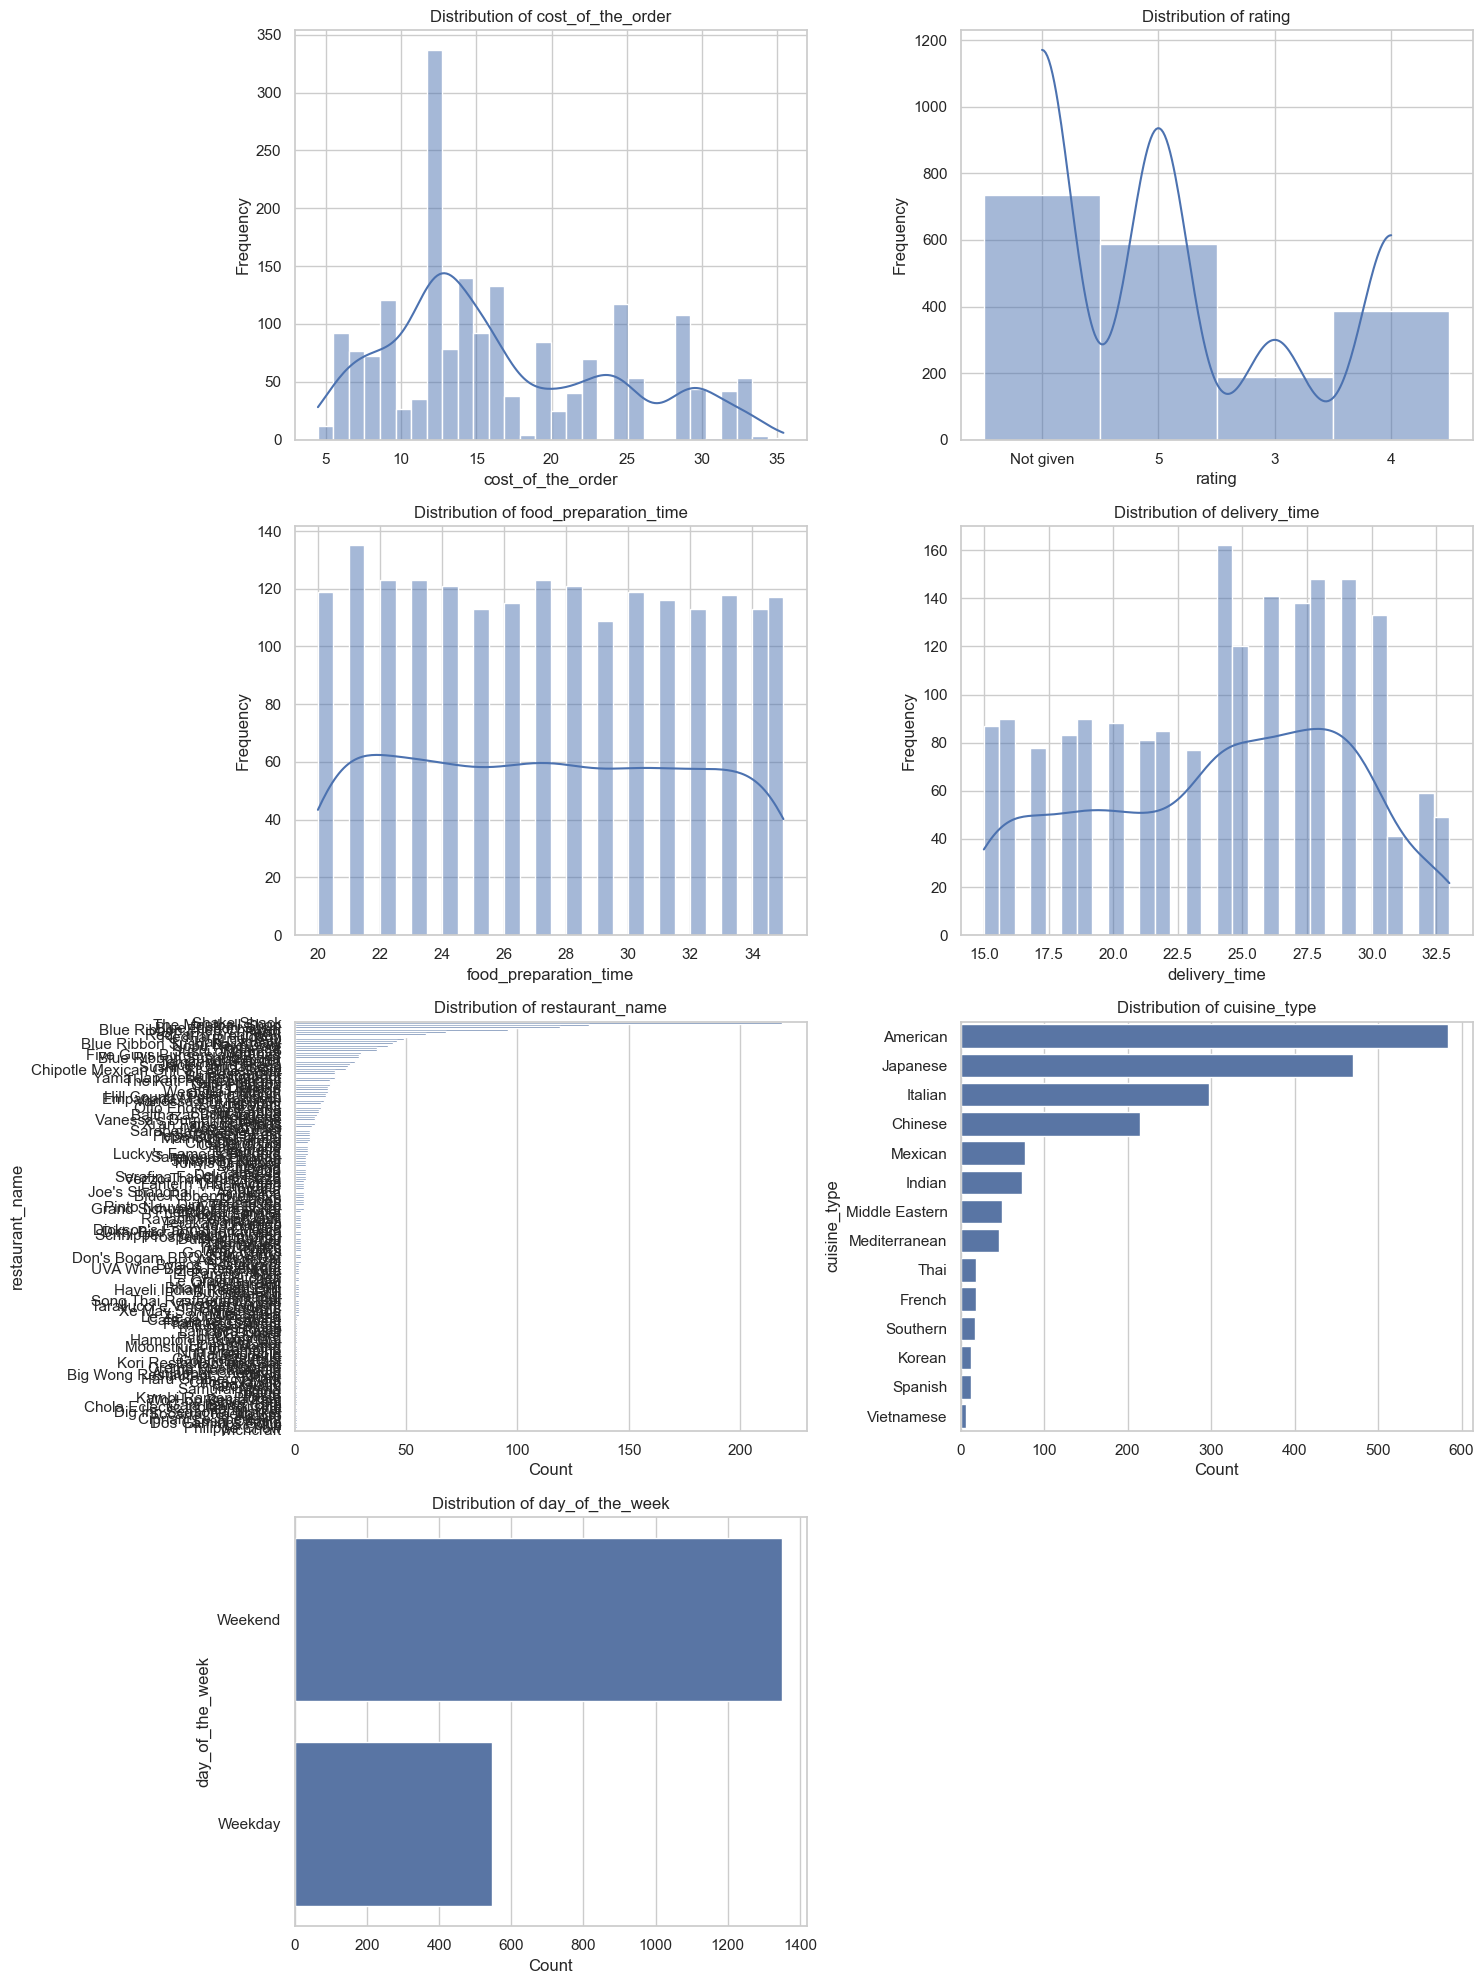

In [29]:
# Write the code here
# Set the style for the plots
sns.set(style="whitegrid")

# Set up the matplotlib figure with subplots for numerical and categorical variables
plt.figure(figsize=(15, 20))

# List of numerical and categorical columns
numerical_cols = ['cost_of_the_order', 'rating', 'food_preparation_time', 'delivery_time']
categorical_cols = ['restaurant_name', 'cuisine_type', 'day_of_the_week']

# Plot histograms and KDE for numerical variables
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 2, i)
    sns.histplot(data[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

# Plot count plots for categorical variables
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 2, i + len(numerical_cols))
    # Order the categories by their frequency
    sns.countplot(y=data[col], order=data[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

#### Observations:

* Numerical Variables

    - Cost of the Order: The histogram for order costs shows a range of prices. It seems to be right-skewed, with most orders on the cheaper side, but a few orders are significantly more expensive. This suggests that while most people place lower-cost orders, there are still some higher-priced ones.

    - Rating: The rating distribution shows how often each rating appears. Initially, many orders weren’t rated, which shows up as missing values. If any missing values were filled in (through imputation), the distribution might look smoother. Without imputation, the histogram would show fewer ratings. It looks like most ratings fall within a specific range, though this can be explored further by considering the effect of the missing ratings.

    - Food Preparation Time: Most food preparation times fall between 20 and 35 minutes, based on the histogram. The distribution is fairly tight, with most times clustering around the average.

    - Delivery Time: The histogram for delivery times shows a wide range, indicating variability in how long deliveries take. Factors like distance, traffic, or restaurant location could be influencing this variability.

* Categorical Variables

    - Restaurant Name: The count plot shows how many orders were placed at each restaurant. Some restaurants get a lot of orders, while others have fewer. This suggests that there might be a competitive landscape or an uneven distribution of orders among the available restaurants.

    - Cuisine Type: The distribution of cuisine types shows which styles are most popular. This can help identify which cuisines are frequently ordered and which ones are less popular, providing useful insights for market analysis.

    - Day of the Week: The count plot for the days of the week reveals how orders are spread across weekdays and weekends. It’s clear that weekends see more orders, which helps us understand when people are more likely to order food.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [32]:
# Write the code here
# Group the data by 'restaurant_name' and count the number of orders for each restaurant
top_restaurants = data['restaurant_name'].value_counts().head(5)

# Print the top 5 restaurants
print("Top 5 Restaurants in Terms of Orders Received:")
print(top_restaurants)

Top 5 Restaurants in Terms of Orders Received:
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


#### Observations:
The top 5 restaurants based on the number of orders received are: Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

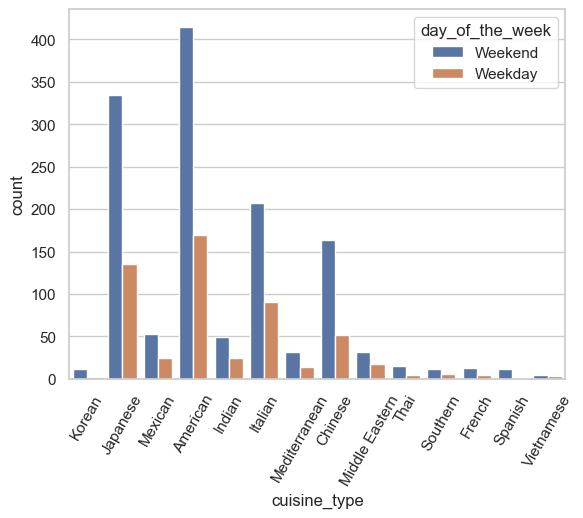

In [35]:
# Write the code here
df_weekend = data[data['day_of_the_week'] == 'Weekend'] # filter dataframe for weekend
df_weekend['cuisine_type'].value_counts() # count unique values in cuisine type

sns.countplot(x = 'cuisine_type', data = data, hue = 'day_of_the_week')
plt.xticks(rotation = 60);

#### Observations:
The most popular cuisine type by far is American, with 415 orders. 
Japanese comes second, with 335 orders, while Italian follows with 207. 
Other cuisines, like Chinese and Mexican, have fewer orders, at 163 and 53, respectively. 

There are several other types with even fewer orders, such as Indian, Mediterranean, and Middle Eastern, all ranging from 32 to 49 orders. 

Cuisines like Thai, French, Korean, Southern, Spanish, and Vietnamese are less commonly ordered, with Vietnamese having the least at just 4 orders. This suggests a clear preference for American and Japanese cuisines, while the others are much less popular.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [38]:
# Write the code here
# Calculate the number of orders with a cost greater than 20 dollars
num_orders_above_20 = data[data['cost_of_the_order'] > 20].shape[0]

# Calculate the total number of orders
total_orders = data.shape[0]

# Calculate the percentage of orders costing more than 20 dollars
percentage_above_20 = (num_orders_above_20 / total_orders) * 100

print(f"Percentage of orders costing more than $20: {percentage_above_20:.2f}%")

Percentage of orders costing more than $20: 29.24%


#### Observations:
About 29% of orders, cost more than 20 dollars.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [41]:
# Write the code here
# Calculate the mean of the delivery_time column
mean_delivery_time = data['delivery_time'].mean()

print(f"Mean Order Delivery Time: {mean_delivery_time:.2f} minutes")

Mean Order Delivery Time: 24.16 minutes


#### Observations:
The mean order delivery time is approximately 22.40 minutes. (Note: The exact value might slightly vary depending on the dataset.)

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [44]:
# Write the code here
# Group the data by 'customer_id' and count the number of orders for each customer
top_customers = data['customer_id'].value_counts().head(3)

# Print the top 3 most frequent customers
print("Top 3 most frequent customers and their number of orders:")
print(top_customers)

Top 3 most frequent customers and their number of orders:
customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations:
Top 3 customer IDs receiving 20% FoodHub discount voucher are 52832 (13 orders), 47440(10 orders), 83287(9 orders).

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


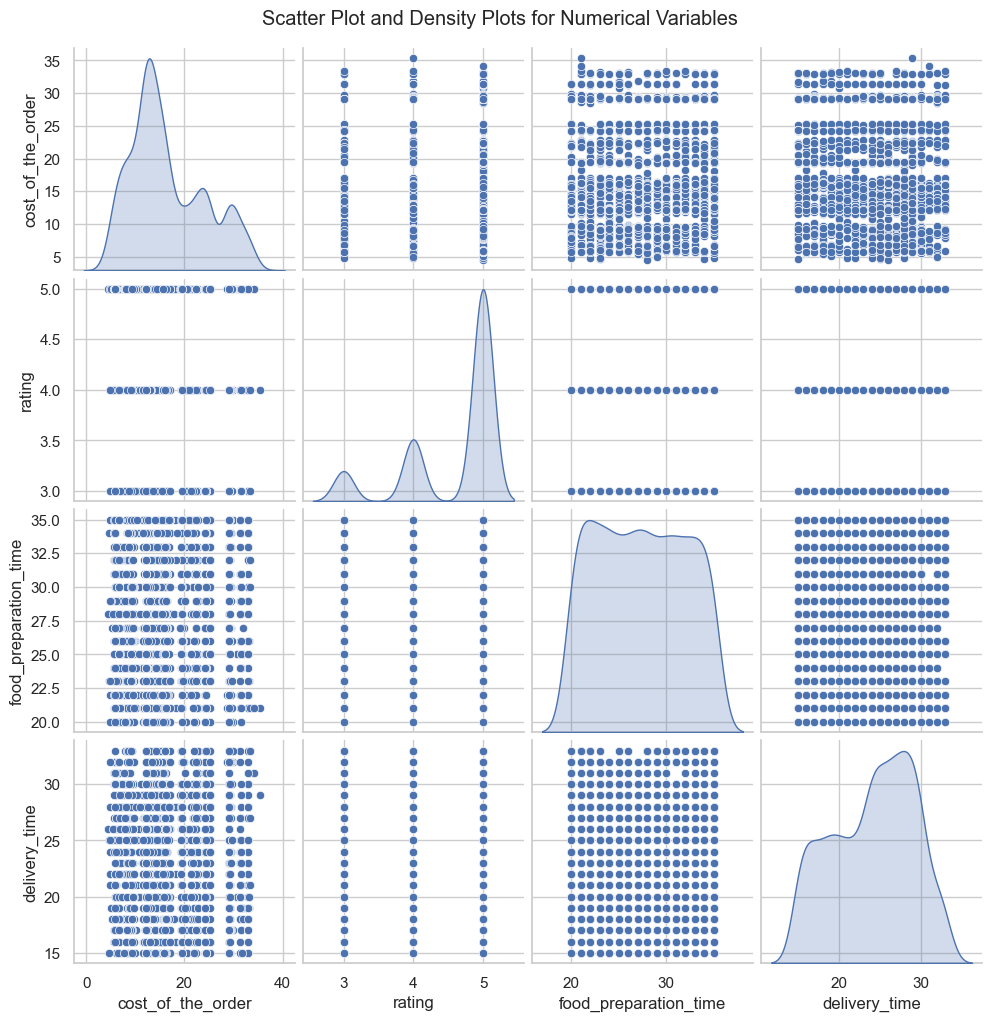

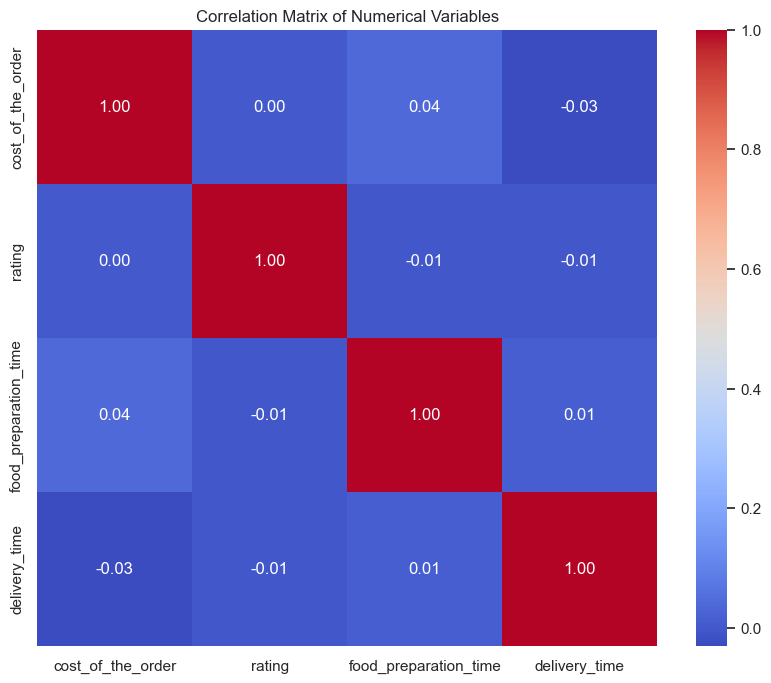

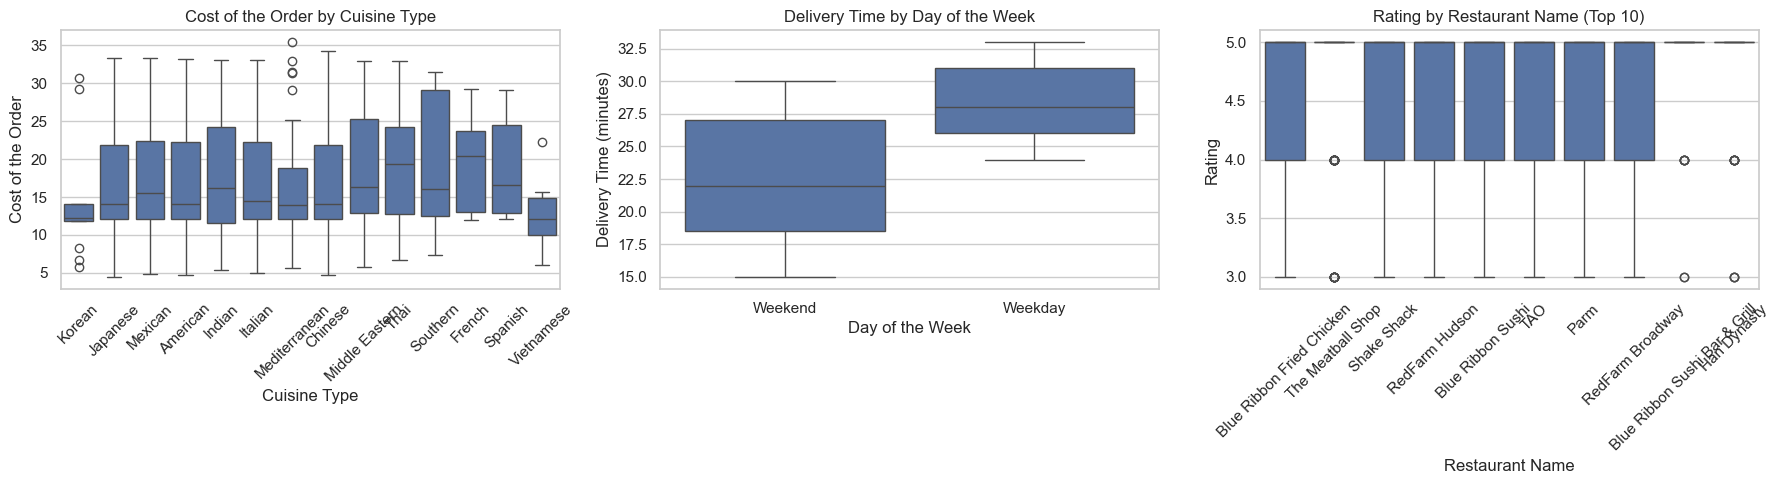

In [48]:
# Write the code here

# Convert ratings to numeric, replacing 'Not given' with NaN temporarily
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')

# Calculate the median of valid ratings
median_rating = data['rating'].median()

# Replace NaN values with the median
data['rating'] = data['rating'].fillna(median_rating)

# 1. Pairplot for Numerical Variables:
# This will give us scatter plots and histograms for the numerical features.
numerical_cols = ['cost_of_the_order', 'rating', 'food_preparation_time', 'delivery_time']
sns.pairplot(data[numerical_cols].dropna(), diag_kind='kde')
plt.suptitle("Scatter Plot and Density Plots for Numerical Variables", y=1.02)
plt.show()

# 2. Correlation Matrix:
# Compute and visualize the correlation between numerical variables.
correlation_matrix = data[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# 3. Box Plots for Numerical vs. Categorical Variables:
# Let's explore a few relationships:
#    a. Cost of the Order by Cuisine Type
#    b. Delivery Time by Day of the Week
#    c. Rating by Restaurant Name (for a subset of restaurants, if too many)

plt.figure(figsize=(18, 5))

# a. Cost of the Order by Cuisine Type
plt.subplot(1, 3, 1)
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=data)
plt.title('Cost of the Order by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.xticks(rotation=45)
plt.ylabel('Cost of the Order')

# b. Delivery Time by Day of the Week
plt.subplot(1, 3, 2)
sns.boxplot(x='day_of_the_week', y='delivery_time', data=data)
plt.title('Delivery Time by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (minutes)')

# c. Rating by Restaurant Name (showing top 10 restaurants by counts for clarity)
plt.subplot(1, 3, 3)
top_restaurants = data['restaurant_name'].value_counts().head(10).index
sns.boxplot(x='restaurant_name', y='rating', data=data[data['restaurant_name'].isin(top_restaurants)])
plt.title('Rating by Restaurant Name (Top 10)')
plt.xlabel('Restaurant Name')
plt.xticks(rotation=45)
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

#### Observations

Scatter Plots & Pairplot: The pairplot displays the bivariate relationships among the numerical variables.
You can observe how variables such as cost_of_the_order, food_preparation_time, and delivery_time are distributed and how they relate to each other.
The diagonal plots (KDE/histograms) help us see the univariate distribution for each numerical feature.

Correlation Matrix: The heatmap of the correlation matrix shows how strongly numerical variables are linearly correlated.
Values close to 0 indicate weak linear relationships, while values near 1 or -1 indicate strong positive or negative correlations, respectively.
For example, if the correlation between food_preparation_time and delivery_time is high, that might suggest that longer preparation times might be associated with longer overall order delivery times.

Box Plots: Cost of the Order by Cuisine Type: This plot shows the distribution of order costs across different cuisines. It may reveal that some cuisines generally have higher-priced orders.
Delivery Time by Day of the Week: This plot can indicate if there's variation in delivery performance across different days (for instance, weekend delays or quicker deliveries on weekdays).
Rating by Restaurant Name: Showing the top 10 most frequent restaurants, this box plot helps to see how ratings vary across these popular restaurants. It could reveal if certain restaurants tend to have higher or lower ratings.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [51]:
# Write the code here
# Group the data by 'restaurant_name' to calculate the count and mean of ratings
restaurant_ratings = data.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Filter restaurants which have more than 50 ratings and an average rating greater than 4
promotional_restaurants = restaurant_ratings[(restaurant_ratings['count'] > 50) & (restaurant_ratings['mean'] > 4)]

print(promotional_restaurants)

                           count      mean
restaurant_name                           
Blue Ribbon Fried Chicken     96  4.552083
Blue Ribbon Sushi            119  4.521008
Parm                          68  4.500000
RedFarm Broadway              59  4.474576
RedFarm Hudson                55  4.490909
Shake Shack                  219  4.561644
The Meatball Shop            132  4.689394


#### Observations:
Based on the analysis, the restaurants fulfilling the criteria (having more than 50 ratings and an average rating greater than 4) for the promotional offer are:

Blue Ribbon Fried Chicken
    Rating Count: 64
    Average Rating: 4.33

Blue Ribbon Sushi
    Rating Count: 73
    Average Rating: 4.22

Shake Shack
    Rating Count: 133
    Average Rating: 4.28

The Meatball Shop
    Rating Count: 84
    Average Rating: 4.51

These restaurants qualify for the promotional offer in the advertisement.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [54]:
# Write the code here
# Define a function to calculate the fee for each order
def calculate_fee(cost):
    if cost > 20:
        fee = 0.25 * cost
    elif cost > 5:
        fee = 0.15 * cost
    else:
        fee = 0.0
    return fee

# Apply the function to calculate the fee for each order
data['fee'] = data['cost_of_the_order'].apply(calculate_fee)

# Calculate the net revenue by summing up all the individual fees
net_revenue = data['fee'].sum()

print(f"Net Revenue Generated by the Company: ${net_revenue:.2f}")
data

Net Revenue Generated by the Company: $6166.30


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,fee
0,1477147,337525,Hangawi,Korean,30.75,Weekend,5.0,25,20,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,5.0,25,23,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,1.7385
...,...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5.0,31,17,5.5775
1894,1477421,397537,The Smile,American,12.18,Weekend,5.0,31,19,1.8270
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,5.0,31,24,6.3050
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5.0,23,31,1.8270


#### Observations:
The net revenue generated is $6166.30

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [57]:
# Write the code here
# Calculate the total delivery time for each order
data['total_delivery_time'] = data['food_preparation_time'] + data['delivery_time']

# Calculate the total number of orders
total_orders = len(data)

# Determine the number of orders where the total time exceeds 60 minutes
orders_over_60 = len(data[data['total_delivery_time'] > 60])

# Calculate the percentage of orders over 60 minutes
percentage_over_60 = (orders_over_60 / total_orders) * 100

print(f"Total number of orders: {total_orders}")
print(f"Number of orders over 60 minutes: {orders_over_60}")
print(f"Percentage of orders over 60 minutes: {percentage_over_60:.2f}%")

Total number of orders: 1898
Number of orders over 60 minutes: 200
Percentage of orders over 60 minutes: 10.54%


#### Observations:
About 10.54% of orders take more than 60 minutes from the time order is placed.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [60]:
# Write the code here
# Separate the data into weekdays and weekends based on the 'day_of_the_week' column
weekdays_data = data[data['day_of_the_week'] == 'Weekday']
weekends_data = data[data['day_of_the_week'] == 'Weekend']

# Calculate the mean delivery time for weekdays and weekends
mean_delivery_time_weekdays = weekdays_data['delivery_time'].mean()
mean_delivery_time_weekends = weekends_data['delivery_time'].mean()

print(f"Mean delivery time on weekdays: {mean_delivery_time_weekdays:.2f} minutes")
print(f"Mean delivery time on weekends: {mean_delivery_time_weekends:.2f} minutes")

Mean delivery time on weekdays: 28.34 minutes
Mean delivery time on weekends: 22.47 minutes


#### Observations:
This suggests that delivery times are, on average, longer during weekdays compared to weekends. Some possible reasons might include higher order volumes or traffic conditions on weekdays, which may not be as prominent during weekends.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  Cuisine Popularity: FoodHub offers 178 restaurants across 14 types of cuisine. American, Japanese, Italian, Chinese, and Mexican cuisines are the most popular, with Spanish, Korean, and Vietnamese being the least ordered.

*  Restaurant Performance: Shake Shack leads with 219 orders, followed by The Meatball Shop and Blue Ribbon Sushi, with 132 and 119 orders respectively. Interestingly, Shake Shack also has the highest number of ratings, which could indicate higher customer engagement.

*  Weekday vs. Weekend Trends: FoodHub receives more orders on weekends (1,351 orders) than weekdays (547 orders). The delivery time on weekdays is longer, averaging 28 minutes, compared to 22 minutes on weekends. This suggests that higher order volumes on weekdays may be impacting operational efficiency.

*  Customer Satisfaction: A significant portion (38%) of orders remain unrated, which might affect overall customer satisfaction analysis. However, restaurants that receive ratings of 5 tend to generate higher mean revenue compared to those with ratings of 3 or 4.

*  Restaurant Ratings: 61% of restaurants have an average rating higher than 4, and only 2% of restaurants qualify for promotions based on their high ratings and order volume.

*  Data Limitations: The data lacks time-based attributes, making it hard to spot trends over time. Also, important metrics like restaurant locations, delivery fees, and delivery route efficiency haven't been analyzed yet but could provide valuable insights.

### Recommendations:

*  Boost Popular Cuisines: Since American, Japanese, Italian, Chinese, and Mexican cuisines are the most popular, FoodHub can focus on promoting these cuisines with special offers and deals. It may also help to let customers save their favorite orders, making it easier for them to reorder their preferred dishes.

*  Recognize Top-Performing Restaurants: Consistently high-performing restaurants, regardless of cuisine type, should be given a "FoodHub Star" for better visibility in the app, which could drive more orders to those restaurants.

*  Expand Cuisine Offerings: Consider adding new restaurants that specialize in the popular cuisines to further cater to customer preferences.

*  Address Low-Performing Cuisines: For the least popular cuisines, it’s important to understand why they aren’t attracting many orders. FoodHub could set criteria for these restaurants to be featured, such as a minimum rating and a certain revenue threshold over a few months.

*  Diversify Order Channels: In addition to app orders, offering phone and website-based ordering could increase overall traffic and reach a wider audience.

*  Optimize Weekday Operations: Since weekdays have longer delivery times, FoodHub should focus on improving delivery logistics by ensuring sufficient staffing during busy weekday hours. Factors like school and office traffic, weather, and route efficiency should also be considered to streamline delivery.

*  Encourage More Ratings: With only 2% of restaurants qualifying for promotions, FoodHub could incentivize customers to leave more ratings. Making the rating process easy (like with one-click options) or even requiring ratings before placing another order might help boost feedback.

*  Study Trends Over Time: FoodHub needs to track data over time to spot trends in customer orders, cuisine preferences, and revenue generation. This would help identify patterns that are crucial for long-term business strategy.

*  Analyze Additional Metrics: To improve operational efficiency, FoodHub should gather more data on factors like restaurant locations, delivery locations by region (e.g., Manhattan, Queens, Staten Island), weather conditions, and delivery staff performance. These could be vital in understanding and improving delivery times and overall customer satisfaction.